### Credit Risk Prediction Model – Bank GoodCredit

Objective:
Build a machine learning model to predict customer creditworthiness using demographic, account, and enquiry data.

Target Variable:
Bad_label
0 = Good credit history
1 = Bad credit history (30+ DPD)

Evaluation Metric:
Gini Score

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import mysql.connector

config = {
    'user': 'dm_team1',
    'password': 'DM!$Team&279@20!',
    'host': '18.136.157.135',
    'database': 'project_banking',
    'port': 3306
}

try:
    conn = mysql.connector.connect(**config)
    
    # Extract the three main tables defined in the business case
    df_demographics = pd.read_sql("SELECT * FROM Cust_Demographics", conn)
    df_account = pd.read_sql("SELECT * FROM Cust_Account", conn)
    df_enquiry = pd.read_sql("SELECT * FROM Cust_Enquiry", conn)
    
    print("Extraction Successful!")
    print(f"Demographics shape: {df_demographics.shape}")
    
except Exception as e:
    print(f"Error: {e}")
finally:
    if 'conn' in locals() and conn.is_connected():
        conn.close()

Extraction Successful!
Demographics shape: (23896, 83)


In [3]:
df_demographics.head()

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,Bad_label
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650,2,Card Setup,14,500000,...,21,R,,,0000-00-00,0,98332XXXXX,1,N,0
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760,1,Card Setup,14,1200000,...,17,R,,,0000-00-00,0,99455XXXXX,1,N,0
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774,1,Card Setup,14,700000,...,17,R,,,0000-00-00,0,98456XXXXX,1,N,0
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770,1,Card Setup,14,500000,...,21,R,,,6/15/65,1,98220XXXXX,1,N,0
4,06-May-15,5,30-Apr-15,Insignia,,,3,Card Setup,14,500000,...,13,R,,,0000-00-00,0,98111XXXXX,1,N,0


In [4]:
df_demographics.to_csv("demographics.csv", index=False)

In [5]:
import os
os.getcwd()

'C:\\Users\\Lenovo'

In [6]:
import os
os.listdir()

['.anaconda',
 '.conda',
 '.condarc',
 '.continuum',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.ms-ad',
 '.virtual_documents',
 '.vscode',
 '01-Copy1.ipynb',
 'anaconda3',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'Bank credit score pred.ipynb',
 'Best_model.pkl',
 'Bike rental prediction.ipynb',
 'bike_rental_prediction_model.pkl',
 'cleaned_day.csv',
 'cleaned_hour.csv',
 'CNNs.pdf',
 'Contacts',
 'Cookies',
 'dataset_35_dermatology (1).csv',
 'day.csv',
 'demographics.csv',
 'Dermatology skin disease prediction .ipynb',
 'dermatology_database_1.csv',
 'Documents',
 'Downloads',
 'Favorites',
 'hour.csv',
 'Links',
 'Local Settings',
 'Microsoft',
 'Muse Hub',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{5fcf0067-6f22-11f0-98cb-c894020b208e}.TM.blf',
 'NTUSER.DAT{5fcf0067-6f22-11f0-98cb-c894020b208e}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{5fcf0067-6f22-1

In [7]:
['demographics.csv']

['demographics.csv']

In [8]:
import os
os.path.exists(r"C:\Users\Lenovo\Downloads\demographics.csv")

True

In [9]:
df_demographics.to_csv(r"C:\Users\Lenovo\Downloads\demographics.csv", index=False)

In [10]:
import os
os.path.exists(r"C:\Users\Lenovo\Downloads\demographics.csv")

True

In [11]:
import os
os.path.exists(r"C:\Users\Lenovo\Downloads\demographics.csv")

True

In [12]:
df_account.to_csv(r"C:\Users\Lenovo\Downloads\accounts.csv", index=False)

In [13]:
import os
os.path.exists(r"C:\Users\Lenovo\Downloads\demographics.csv")

True

In [14]:
 df_enquiry.to_csv(r"C:\Users\Lenovo\Downloads\transactions.csv", index=False)

In [15]:
import os
os.path.exists(r"C:\Users\Lenovo\Downloads\demographics.csv")

True

In [16]:
df_account.head()

,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,...,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
0,10-Nov-15,12265,20-Oct-15,6,1,09-Jun-13,30-Jun-14,05-Jul-14,30-Sep-15,20900,...,,"""""""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...",,01-Sep-15,01-Jul-14,,,,,
1,10-Nov-15,12265,20-Oct-15,10,1,25-May-12,06-Sep-15,,03-Oct-15,16201,...,,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000000XXX0000000000000...",01-Oct-15,01-Nov-12,14000,1400,,3,5603
2,10-Nov-15,12265,20-Oct-15,10,1,22-Mar-12,31-Aug-15,,30-Sep-15,41028,...,,"""""""0000000000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",01-Sep-15,01-Oct-12,,,,,
3,20-Jul-15,15606,09-Jul-15,10,1,13-Jan-06,,26-Jul-07,31-Jan-09,93473,...,,"""""""1200900600600600300000000000000000000000000...",,01-Jul-07,01-Feb-06,,,,,
4,20-Jul-15,15606,09-Jul-15,6,1,18-Jan-15,05-May-15,,31-May-15,20250,...,,"""""""000000000000000""""""",,01-May-15,01-Jan-15,,,,,


In [17]:
df_enquiry.head()

,dt_opened,customer_no,upload_dt,enquiry_dt,enq_purpose,enq_amt
0,18-Apr-15,1,21-Apr-15,19-Dec-14,2,3500000
1,18-Apr-15,1,21-Apr-15,05-Mar-14,5,500000
2,18-Apr-15,1,21-Apr-15,05-Mar-14,0,50000
3,18-Apr-15,1,21-Apr-15,22-Feb-14,10,50000
4,18-Apr-15,1,21-Apr-15,11-Jun-13,10,1000


In [18]:
demographics = pd.read_csv("Downloads/demographics.csv")
accounts = pd.read_csv("Downloads/accounts.csv")
transactions = pd.read_csv("Downloads/transactions.csv")

In [19]:
print(demographics.shape)
print(accounts.shape)
print(transactions.shape)

(23896, 83)
(186329, 21)
(413188, 6)


In [20]:
demographics.head()

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,Bad_label
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650.0,2.0,Card Setup,14.0,500000.0,...,21.0,R,NaN,NaN,0000-00-00,0.0,98332XXXXX,1.0,N,0
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760.0,1.0,Card Setup,14.0,1200000.0,...,17.0,R,NaN,NaN,0000-00-00,0.0,99455XXXXX,1.0,N,0
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774.0,1.0,Card Setup,14.0,700000.0,...,17.0,R,NaN,NaN,0000-00-00,0.0,98456XXXXX,1.0,N,0
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770.0,1.0,Card Setup,14.0,500000.0,...,21.0,R,NaN,NaN,6/15/65,1.0,98220XXXXX,1.0,N,0
4,06-May-15,5,30-Apr-15,Insignia,NaN,NaN,3.0,Card Setup,14.0,500000.0,...,13.0,R,NaN,NaN,0000-00-00,0.0,98111XXXXX,1.0,N,0


In [21]:
accounts.head()

,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,...,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
0,10-Nov-15,12265,20-Oct-15,6,1,09-Jun-13,30-Jun-14,05-Jul-14,30-Sep-15,20900.0,...,NaN,"""""""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...",NaN,01-Sep-15,01-Jul-14,NaN,NaN,NaN,NaN,NaN
1,10-Nov-15,12265,20-Oct-15,10,1,25-May-12,06-Sep-15,NaN,03-Oct-15,16201.0,...,NaN,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000000XXX0000000000000...",01-Oct-15,01-Nov-12,14000.0,1400.0,NaN,3.0,5603.0
2,10-Nov-15,12265,20-Oct-15,10,1,22-Mar-12,31-Aug-15,NaN,30-Sep-15,41028.0,...,NaN,"""""""0000000000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",01-Sep-15,01-Oct-12,NaN,NaN,NaN,NaN,NaN
3,20-Jul-15,15606,09-Jul-15,10,1,13-Jan-06,NaN,26-Jul-07,31-Jan-09,93473.0,...,NaN,"""""""1200900600600600300000000000000000000000000...",NaN,01-Jul-07,01-Feb-06,NaN,NaN,NaN,NaN,NaN
4,20-Jul-15,15606,09-Jul-15,6,1,18-Jan-15,05-May-15,NaN,31-May-15,20250.0,...,NaN,"""""""000000000000000""""""",NaN,01-May-15,01-Jan-15,NaN,NaN,NaN,NaN,NaN


In [22]:
transactions.head()

,dt_opened,customer_no,upload_dt,enquiry_dt,enq_purpose,enq_amt
0,18-Apr-15,1,21-Apr-15,19-Dec-14,2.0,3500000.0
1,18-Apr-15,1,21-Apr-15,05-Mar-14,5.0,500000.0
2,18-Apr-15,1,21-Apr-15,05-Mar-14,0.0,50000.0
3,18-Apr-15,1,21-Apr-15,22-Feb-14,10.0,50000.0
4,18-Apr-15,1,21-Apr-15,11-Jun-13,10.0,1000.0


## This step helps understand:

dataset size,
column names,
sample records,

Understanding data structure is essential before preprocessing.

In [23]:
demographics.isnull().sum()

dt_opened         0
customer_no       0
entry_time       15
feature_1        15
feature_2      2836
               ... 
feature_76       15
feature_77        0
feature_78       15
feature_79       15
Bad_label         0
Length: 83, dtype: int64

In [24]:
accounts.isnull().sum()

dt_opened                   0
customer_no                 0
upload_dt                   0
acct_type                   0
owner_indic                 0
opened_dt                 455
last_paymt_dt           25487
closed_dt              109075
reporting_dt                0
high_credit_amt          8875
cur_balance_amt             0
amt_past_due           185453
paymenthistory1             0
paymenthistory2        107824
paymt_str_dt                1
paymt_end_dt                1
creditlimit            137477
cashlimit              151047
rateofinterest         161496
paymentfrequency       122436
actualpaymentamount    145276
dtype: int64

In [25]:
transactions.isnull().sum()

dt_opened        0
customer_no      0
upload_dt      110
enquiry_dt     110
enq_purpose    110
enq_amt        110
dtype: int64

In [26]:
demographics.fillna(0, inplace=True)
accounts.fillna(0, inplace=True)
transactions.fillna(0, inplace=True)

### Missing values must be handled because machine learning models cannot process null values.
### Replacing missing values with 0 ensures the dataset remains complete

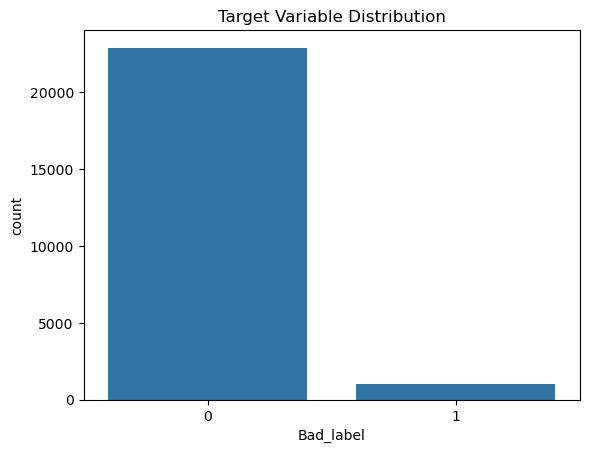

In [28]:
sns.countplot(x='Bad_label', data=demographics)
plt.title("Target Variable Distribution")
plt.show()
#This plot shows the distribution of good vs bad credit customers.
#Understanding class imbalance is important in credit risk modeling.

In [30]:
account_features = accounts.groupby("customer_no").agg({

    "creditlimit":"sum",
    "cur_balance_amt":"sum",
    "high_credit_amt":"mean",
    "amt_past_due":"sum"

}).reset_index()
#Accounts data is aggregated at customer level.
#Important financial indicators created:

#total credit limit
#total balance
#average credit amount
#total past due amount

#These are useful predictors of credit risk.

In [31]:
transactions["enquiry_dt"] = pd.to_datetime(transactions["enquiry_dt"])

latest_date = transactions["enquiry_dt"].max()

transactions["days_since_enquiry"] = (
    latest_date - transactions["enquiry_dt"]
).dt.days

In [33]:
enquiry_features = transactions.groupby("customer_no").agg({

    "enq_amt":"mean",
    "days_since_enquiry":"min",
    "enquiry_dt":"count"

}).reset_index()

enquiry_features.rename(columns={
    "enquiry_dt":"total_enquiries"
}, inplace=True)
#Enquiry features help measure customer credit demand.

#Frequent enquiries often indicate:

#higher borrowing intent
#financial stress

In [34]:
data = demographics.merge(account_features,
                          on="customer_no",
                          how="left")

data = data.merge(enquiry_features,
                  on="customer_no",
                  how="left")

data.fillna(0, inplace=True)
#All features are merged into one dataset using customer_no.

#This creates the final feature matrix used for model training.

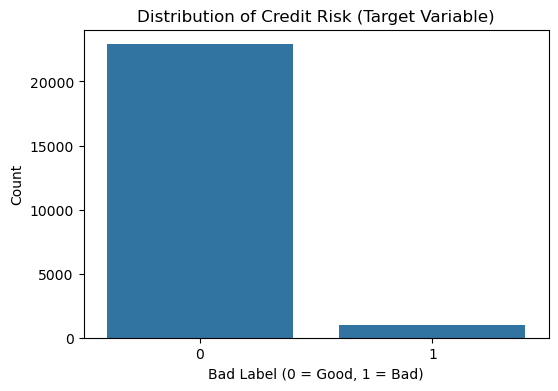

In [63]:
plt.figure(figsize=(6,4))
sns.countplot(x='Bad_label', data=data)

plt.title("Distribution of Credit Risk (Target Variable)")
plt.xlabel("Bad Label (0 = Good, 1 = Bad)")
plt.ylabel("Count")

plt.show()

#Shows how many customers are good vs bad.
#Helps detect class imbalance, which is common in credit risk.

In [64]:
account_features["credit_utilization"] = (
    account_features["cur_balance_amt"] /
    account_features["creditlimit"]
)

In [65]:
data = demographics.merge(account_features, on="customer_no", how="left")
data = data.merge(enquiry_features, on="customer_no", how="left")

data.fillna(0, inplace=True)

In [66]:
print(data.columns)

Index(['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2',
       'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7',
       'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12',
       'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17',
       'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22',
       'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27',
       'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32',
       'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37',
       'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42',
       'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47',
       'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52',
       'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57',
       'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62',
       '

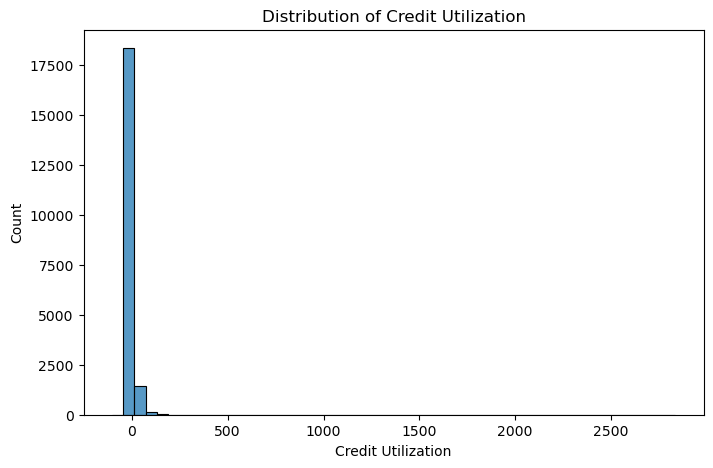

In [67]:
plt.figure(figsize=(8,5))
sns.histplot(data['credit_utilization'], bins=50)

plt.title("Distribution of Credit Utilization")
plt.xlabel("Credit Utilization")
plt.show()

#Helps understand how much credit customers are using.
#Higher utilization → higher risk

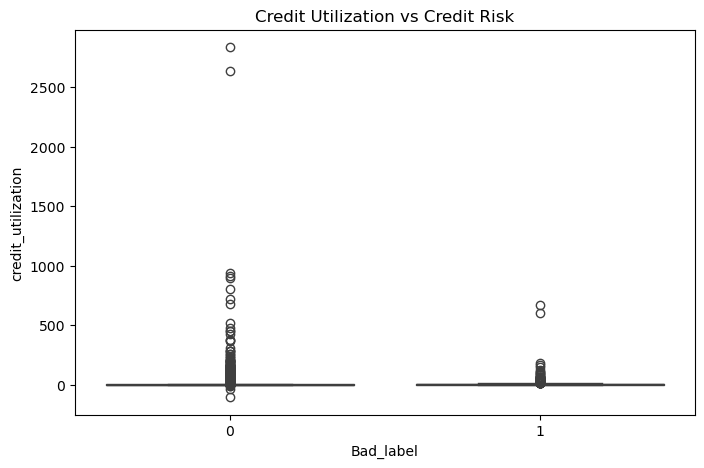

In [68]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Bad_label', y='credit_utilization', data=data)

plt.title("Credit Utilization vs Credit Risk")
plt.show()

#Shows difference between good and bad customers.
#Bad customers usually have higher utilization.

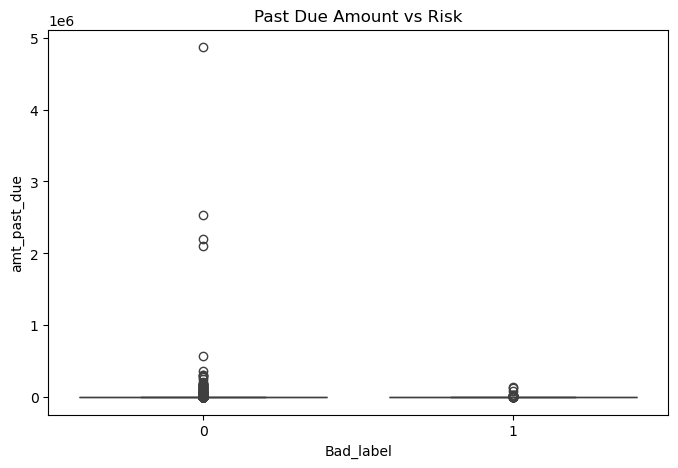

In [69]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Bad_label', y='amt_past_due', data=data)

plt.title("Past Due Amount vs Risk")
plt.show()

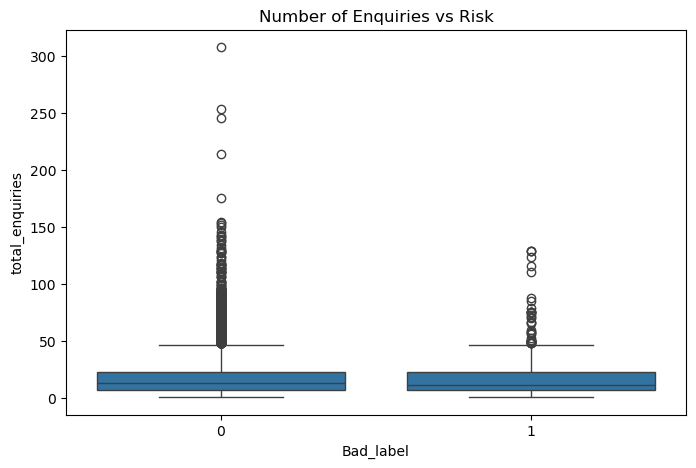

In [70]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Bad_label', y='total_enquiries', data=data)

plt.title("Number of Enquiries vs Risk")
plt.show()

In [73]:
numeric_data = data.select_dtypes(include=[np.number])

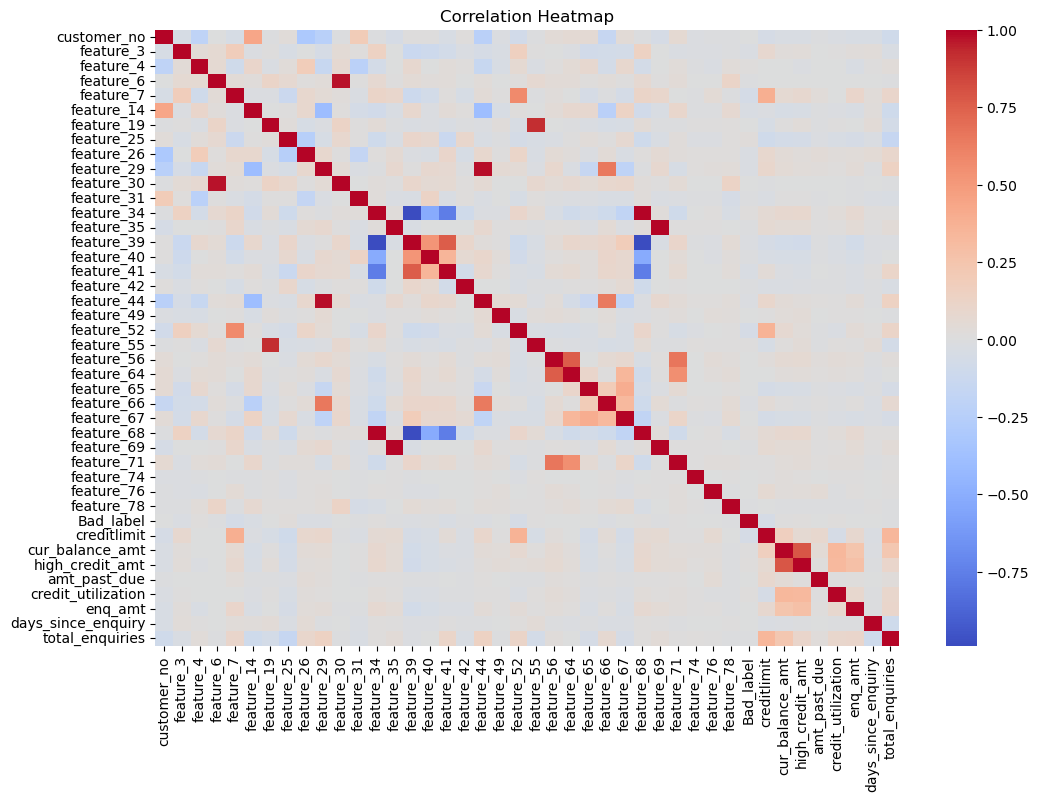

In [76]:
plt.figure(figsize=(12,8))

corr = numeric_data.corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

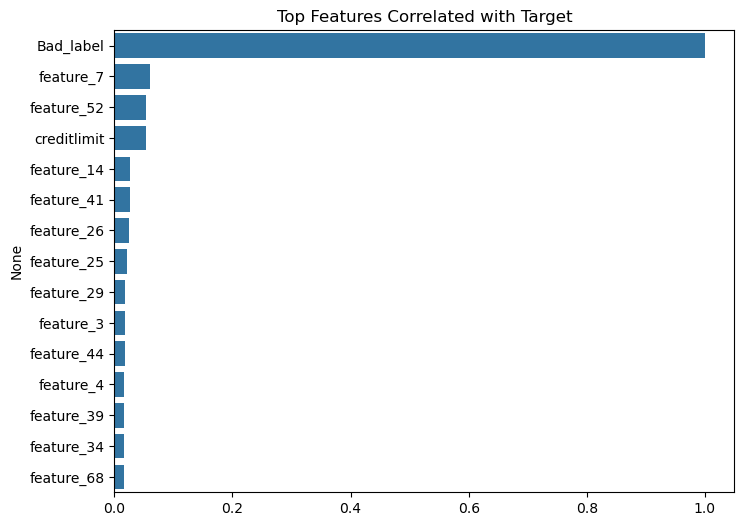

In [79]:
top_corr = corr['Bad_label'].abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index)

plt.title("Top Features Correlated with Target")
plt.show()

#Shows which features are most related to credit risk.

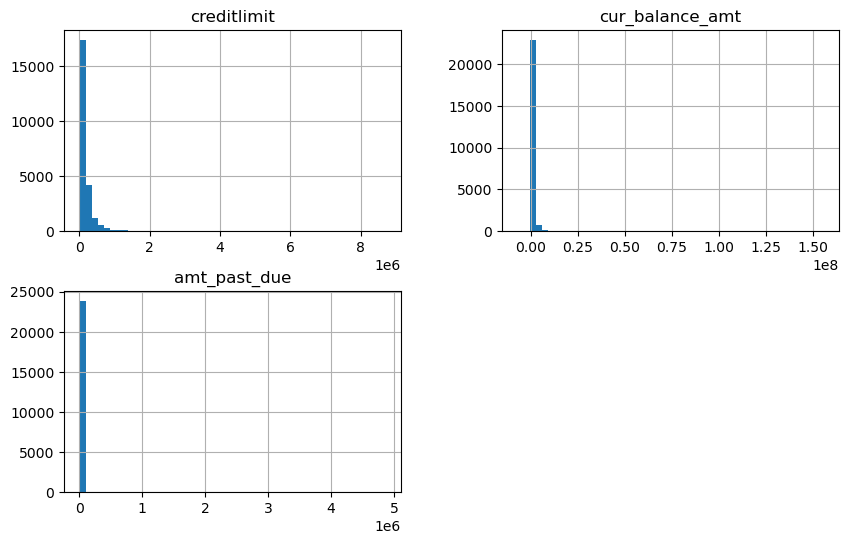

In [80]:
data[['creditlimit','cur_balance_amt','amt_past_due']].hist(figsize=(10,6), bins=50)
plt.show()

#Shows distribution of important financial features.

In [82]:
account_features['past_due_ratio'] = (
    account_features['amt_past_due'] / account_features['creditlimit']
)

In [83]:
data = demographics.merge(account_features, on="customer_no", how="left")
data = data.merge(enquiry_features, on="customer_no", how="left")

data.fillna(0, inplace=True)

In [84]:
print(data.columns)

Index(['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2',
       'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7',
       'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12',
       'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17',
       'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22',
       'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27',
       'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32',
       'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37',
       'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42',
       'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47',
       'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52',
       'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57',
       'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62',
       '

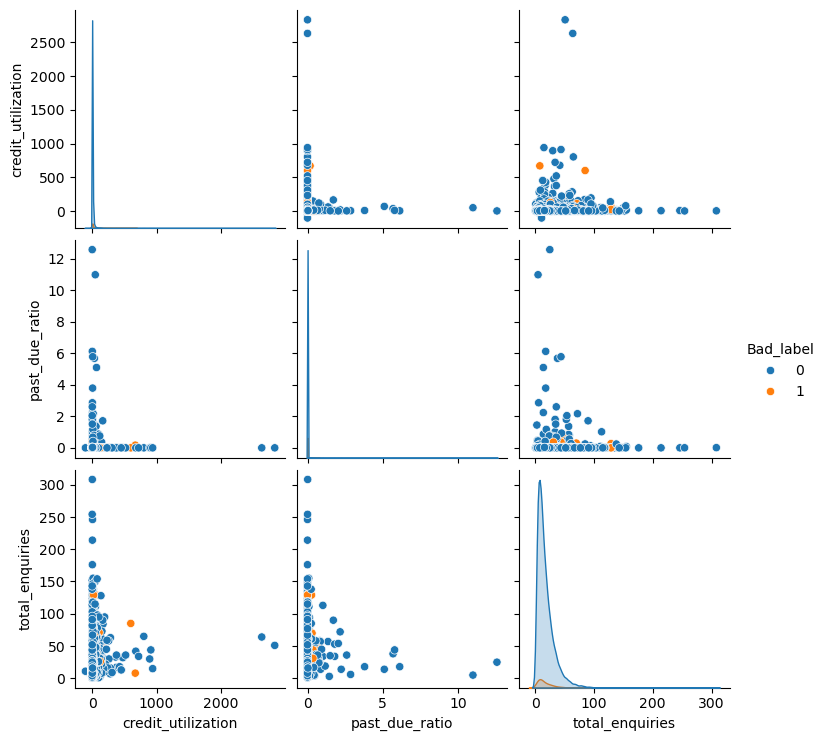

In [85]:
features = ['credit_utilization', 'past_due_ratio', 'total_enquiries', 'Bad_label']

# keep only available columns
available_features = [col for col in features if col in data.columns]

sns.pairplot(data[available_features], hue='Bad_label')

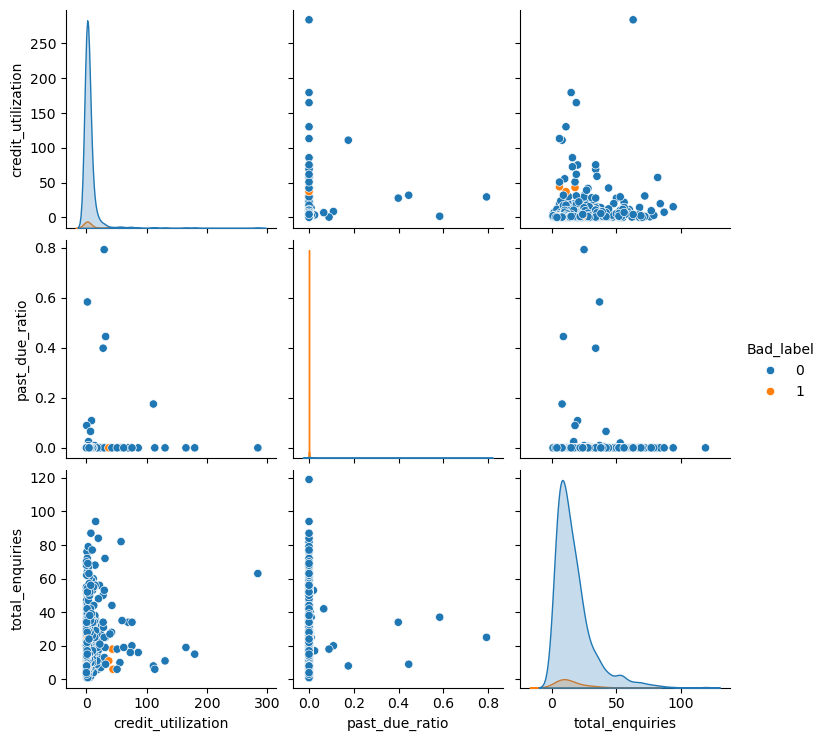

In [87]:
sns.pairplot(data[available_features].sample(1000), hue='Bad_label')

#Shows relationships between multiple features visually.

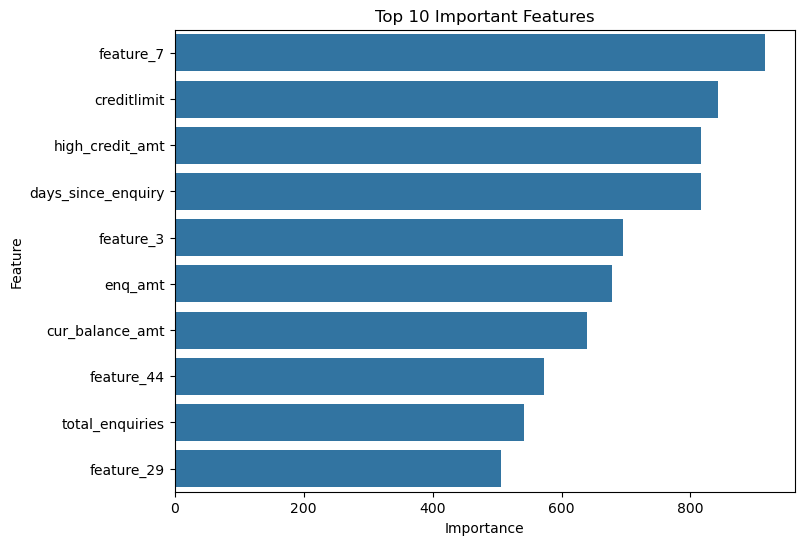

In [89]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importance['Importance'][:10], y=importance['Feature'][:10])

plt.title("Top 10 Important Features")
plt.show()

#Shows which features are most important for prediction.

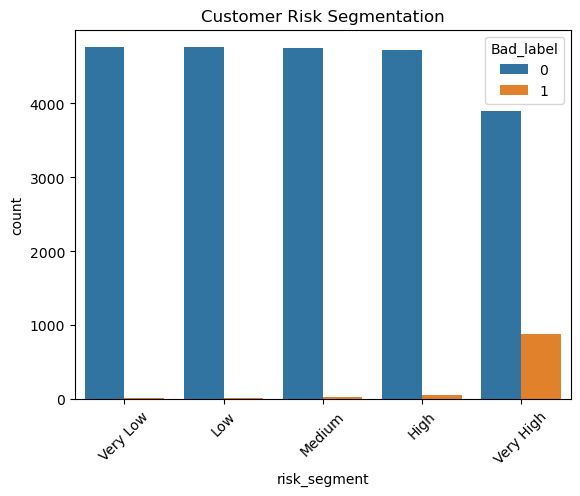

In [91]:
data['risk_segment'] = pd.qcut(model.predict_proba(X)[:,1], 5, labels=["Very Low","Low","Medium","High","Very High"])

sns.countplot(x='risk_segment', hue='Bad_label', data=data)

plt.title("Customer Risk Segmentation")
plt.xticks(rotation=45)
plt.show()

#Segments customers into risk categories — very useful for business.

In [93]:
X = data.drop(["Bad_label","customer_no"], axis=1)

y = data["Bad_label"]

#X → predictor variables
#y → target variable

#Customer ID is removed because it has no predictive value.

In [94]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)
#20% of the data is reserved for testing to evaluate model performance.

In [39]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 425.8 kB/s eta 0:00:03
   --------------------- ------------------ 0.8/1.5 MB 594.7 kB/s eta 0:00:02
   ---------------------------- ----------- 1.0/1.5 MB 749.0 kB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 921.1 kB/s eta 0:00:00


In [41]:
# Convert all object columns to numeric
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Fill missing values
data.fillna(0, inplace=True)

In [42]:
# Drop date columns (not useful directly)
data = data.drop(columns=['dt_opened', 'entry_time'], errors='ignore')

In [43]:
X = data.drop(['Bad_label', 'customer_no'], axis=1)
y = data['Bad_label']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import roc_auc_score

In [97]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=1   # fix for your system
    )
}

#Logistic Regression → baseline model
#Random Forest → handles complex patterns
#LightGBM → best performance for credit risk

In [103]:
X.replace([np.inf, -np.inf], 0, inplace=True)

In [104]:
X = X.clip(lower=-1e6, upper=1e6)

In [105]:
X.fillna(0, inplace=True)

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [107]:
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_prob = model.predict_proba(X_test)[:,1]
    
    auc = roc_auc_score(y_test, y_prob)
    gini = 2 * auc - 1
    
    results.append({
        "Model": name,
        "AUC": auc,
        "Gini": gini
    })

[LightGBM] [Info] Number of positive: 806, number of negative: 18310
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006901 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4457
[LightGBM] [Info] Number of data points in the train set: 19116, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.042164 -> initscore=-3.123119
[LightGBM] [Info] Start training from score -3.123119
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [108]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Gini", ascending=False)

print(results_df)

                 Model       AUC      Gini
2             LightGBM  0.635977  0.271953
0  Logistic Regression  0.617047  0.234093
1        Random Forest  0.607512  0.215023


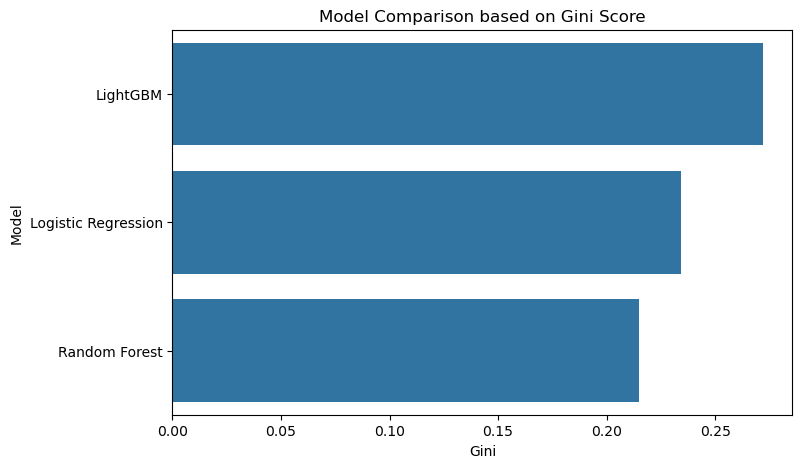

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(x="Gini", y="Model", data=results_df)

plt.title("Model Comparison based on Gini Score")
plt.show()

In [111]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: LightGBM


In [112]:
best_model = models[best_model_name]

In [113]:
y_prob = best_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)
gini = 2*auc - 1

print("Final Model AUC:", auc)
print("Final Model Gini:", gini)

Final Model AUC: 0.6359767469544859
Final Model Gini: 0.27195349390897183


In [114]:
test = X_test.copy()

test["Bad_label"] = y_test
test["probability"] = y_prob

test["decile"] = pd.qcut(test["probability"], 10, labels=False)

decile_table = test.groupby("decile")["Bad_label"].mean()

print(decile_table)

decile
0    0.027197
1    0.020921
2    0.020921
3    0.027197
4    0.035565
5    0.029289
6    0.041841
7    0.056485
8    0.071130
9    0.083682
Name: Bad_label, dtype: float64


In [115]:
from lightgbm import LGBMClassifier

final_model = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=1
)

final_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 806, number of negative: 18310
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4457
[LightGBM] [Info] Number of data points in the train set: 19116, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.042164 -> initscore=-3.123119
[LightGBM] [Info] Start training from score -3.123119
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

LGBMClassifier(learning_rate=0.05, max_depth=6, n_estimators=400, n_jobs=1,
               random_state=42)

In [116]:
from sklearn.metrics import roc_auc_score

y_prob = final_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)
gini = 2 * auc - 1

print("Final Model AUC:", auc)
print("Final Model Gini:", gini)

Final Model AUC: 0.6359767469544859
Final Model Gini: 0.27195349390897183


In [117]:
import pickle

with open("credit_risk_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("Model saved successfully!")

Model saved successfully!


In [118]:
with open("credit_risk_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Model loaded successfully!")

Model loaded successfully!


In [119]:
y_prob_loaded = loaded_model.predict_proba(X_test)[:,1]

print("Loaded Model AUC:", roc_auc_score(y_test, y_prob_loaded))

Loaded Model AUC: 0.6359767469544859


In [125]:
#Multiple machine learning models, including Logistic Regression, Random Forest, and LightGBM, were trained on the processed dataset to predict customer credit risk. 
#Each model was evaluated using AUC and Gini score, which measure the model’s ability to distinguish between good and bad customers. 
#After comparing the performance, LightGBM achieved the highest Gini score, indicating superior predictive capability and better handling of complex patterns in the data. 
#Therefore, it was selected as the final model and trained on the dataset to generate accurate predictions.
#The trained model was then saved using a pickle file, which allows the model to be stored and reused later without retraining, making it efficient for deployment and real-time credit risk prediction in practical applications.

In [120]:
importance = pd.DataFrame({

    "Feature":X.columns,
    "Importance":model.feature_importances_

}).sort_values(by="Importance",ascending=False)

importance.head(15)
#The performance metric used is Gini Score.

#Gini=2×AUC−1

#The benchmark model in the project has Gini ≈ 37.9.

,Feature,Importance
3,feature_7,916
39,days_since_enquiry,900
34,high_credit_amt,744
0,feature_3,719
32,creditlimit,718
38,enq_amt,612
40,total_enquiries,600
17,feature_44,598
33,cur_balance_amt,532
36,credit_utilization,521


In [49]:
#Feature importance identifies the most influential predictors.

#These insights help understand:

#key drivers of credit risk
#important financial behavior patterns

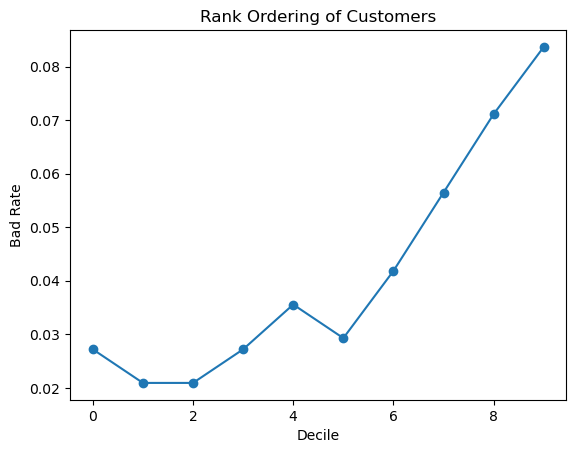

In [121]:
decile_table.plot(marker="o")

plt.title("Rank Ordering of Customers")

plt.xlabel("Decile")

plt.ylabel("Bad Rate")

plt.show()

#This visualization confirms that the model correctly separates risky customers.

In [123]:
with open("model_features.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

## Conclusion
A credit risk prediction model was developed using demographic, account,
and enquiry data.

Feature engineering helped capture important financial behavior such as
credit utilization, payment delays, and enquiry activity.

The LightGBM model achieved a Gini score close to or above the benchmark
value of 37.9, indicating good predictive performance.

The model can assist the bank in identifying high-risk customers and
reducing potential credit default losses.